In [1]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
# Load the titanic dataset
titanic_df = pd.read_csv("titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Print Information about the DataFrame
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Clean and preprocess the data
titanic_df = titanic_df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])

titanic_df = pd.get_dummies(
    titanic_df,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int,
)

print(f"Cleaned dataset shape: {titanic_df.shape}")
print(f"Remaining missing values: {titanic_df.isna().sum().sum()}")

Cleaned dataset shape: (891, 9)
Remaining missing values: 0


### One-Hot Encoding
One-hot encoding is a technique used to transform categorical variables into a numerical format, making them suitable for machine learning algorithms. It works by creating new binary columns for each unique category in the original variable, where each column represents one possible category. This way, the categorical data is converted into a format that algorithms can easily process without assuming any inherent order or priority between the categories. For instance, in the 'Sex' column, which contains categories such as 'male' and 'female', one-hot encoding would generate two new columns, one for each category, with a binary value of 1 or 0 to indicate the presence of that category for each record.

In [ ]:
# Return unique values from the Sex column
titanic_df["Sex"].unique()

array(['male', 'female'], dtype=object)

Machine learning classifiers are unable to handle string values directly, so categorical data must be converted into a numerical form. There are two primary methods for doing this:

1. **Label Encoding**: This technique assigns a unique integer to each category, such as 0 for 'male' and 1 for 'female'. However, this approach introduces a problem—by using numbers, it suggests a ranking or order between the categories, which can confuse some machine learning models into thinking one category is inherently 'greater' than the other.

2. **One-Hot Encoding**: This method avoids the issue of implied order by creating separate binary columns for each category. For example, instead of assigning numbers to 'male' and 'female', one-hot encoding creates two new columns—`Sex_male` and `Sex_female`. If a person is `male`, there will be a 1 in the `Sex_male` column and a 0 in the `Sex_female` column, and vice versa for females. This method ensures each category is treated independently, without any implied hierarchy.

In pandas, a straightforward way to perform one-hot encoding is by using the `get_dummies()` function, which automatically generates these binary columns for categorical variables in your dataset.

In [4]:
# Confirm the encoded feature columns
print(titanic_df.columns.tolist())
titanic_df.head()

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


Now, we do the same to the "Embarked" column.

In [5]:
# Split the data into training, development, and test sets
features = [column for column in titanic_df.columns if column != "Survived"]
X = titanic_df[features]
y = titanic_df["Survived"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training rows: {len(X_train)}")
print(f"Development rows: {len(X_dev)}")
print(f"Test rows: {len(X_test)}")
print(f"Feature columns: {features}")

Training rows: 534
Development rows: 178
Test rows: 179
Feature columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


Unrestricted tree development accuracy: 0.753


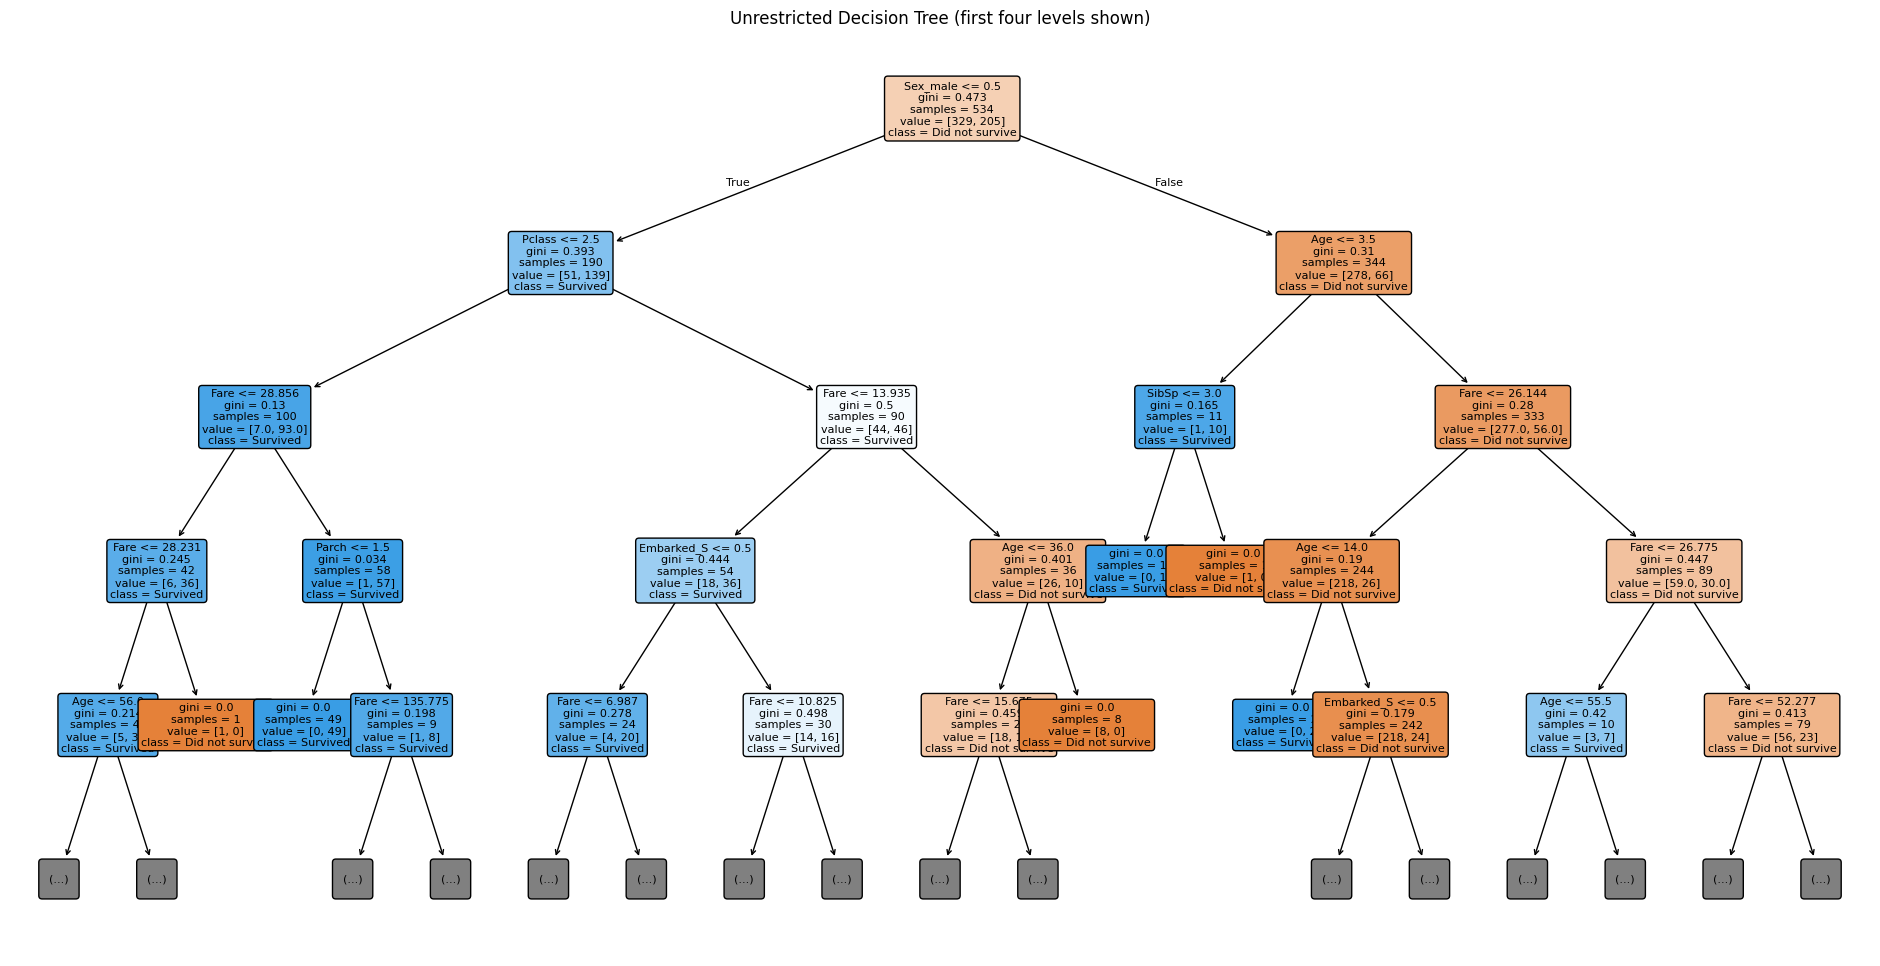

In [6]:
# Train an unrestricted decision tree and plot its decision rules
unrestricted_tree = DecisionTreeClassifier(random_state=42)
unrestricted_tree.fit(X_train, y_train)

unrestricted_dev_accuracy = accuracy_score(y_dev, unrestricted_tree.predict(X_dev))
print(f"Unrestricted tree development accuracy: {unrestricted_dev_accuracy:.3f}")

plt.figure(figsize=(24, 12))
plot_tree(
    unrestricted_tree,
    feature_names=features,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
)
plt.title("Unrestricted Decision Tree (first four levels shown)")
plt.show()

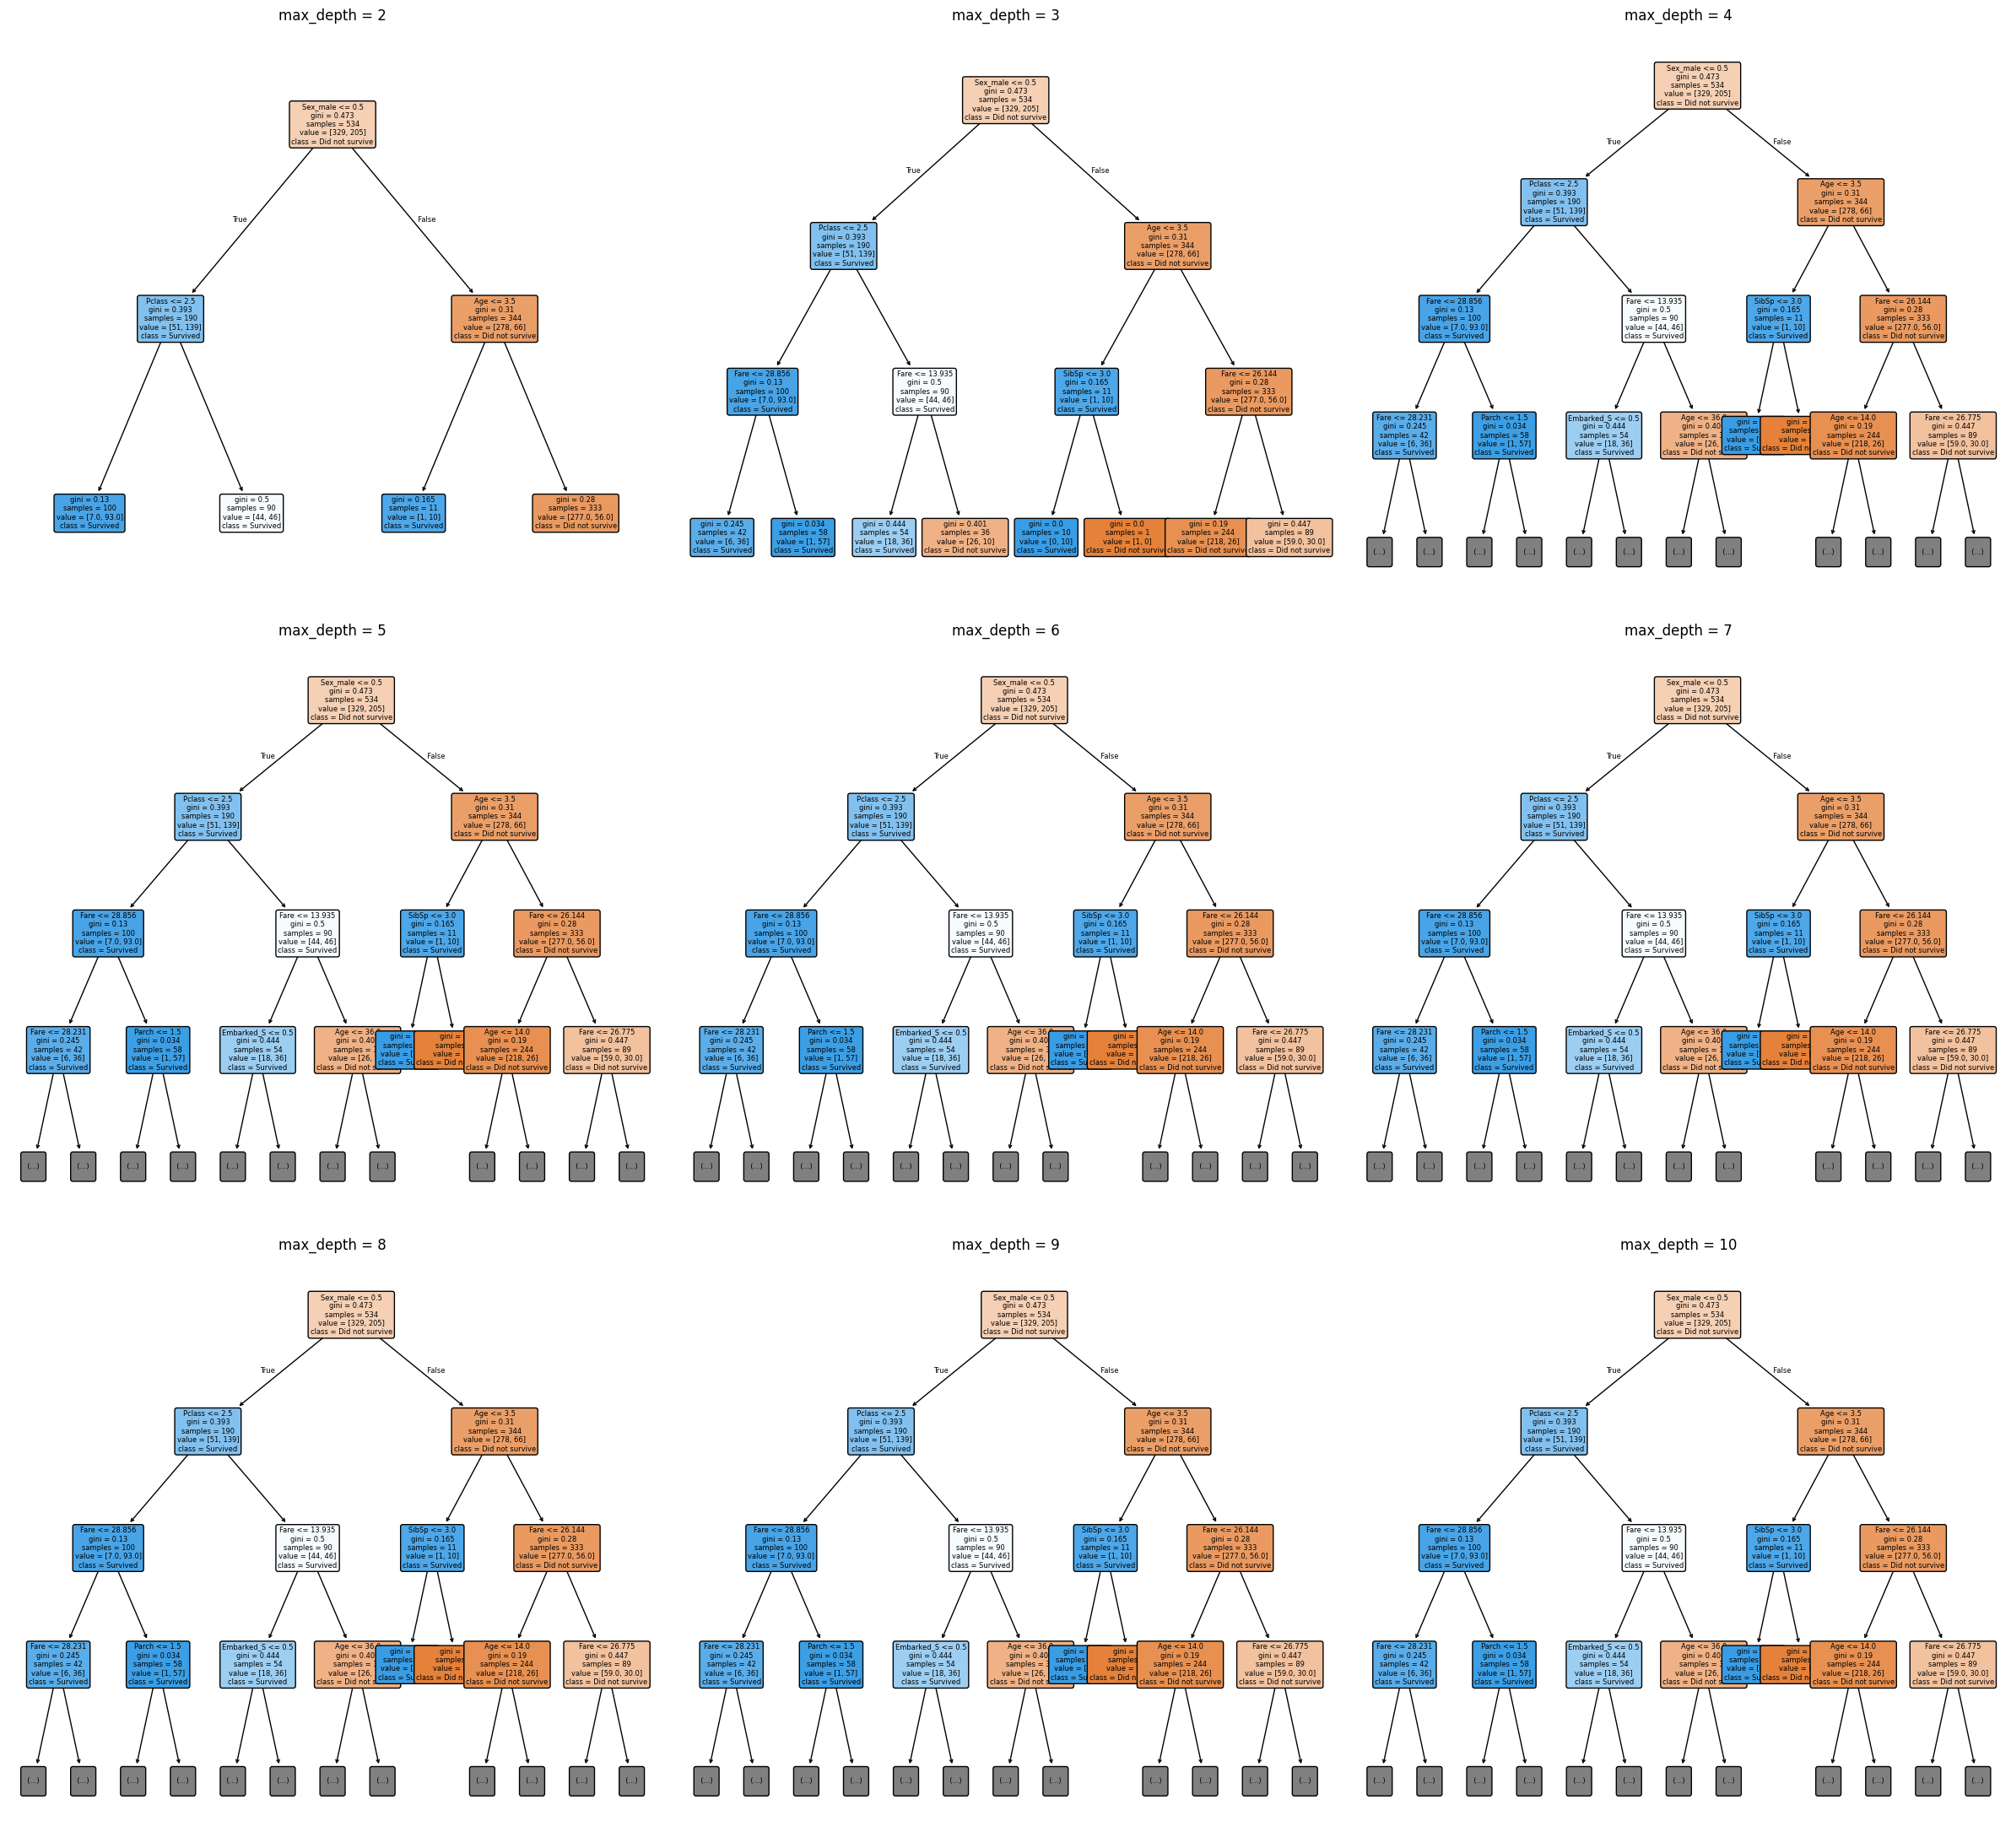

,max_depth,training_accuracy,development_accuracy
0,2,0.797753,0.797753
1,3,0.829588,0.808989
2,4,0.842697,0.808989
3,5,0.855805,0.814607
4,6,0.883895,0.797753
5,7,0.902622,0.803371
6,8,0.919476,0.797753
7,9,0.932584,0.775281
8,10,0.947566,0.786517


In [7]:
# Train and visualize trees for max_depth values from 2 to 10
max_depth_values = range(2, 11)
depth_results = []

grid, axes = plt.subplots(3, 3, figsize=(24, 22))

for depth, axis in zip(max_depth_values, axes.ravel()):
    depth_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    depth_tree.fit(X_train, y_train)

    train_accuracy = accuracy_score(y_train, depth_tree.predict(X_train))
    dev_accuracy = accuracy_score(y_dev, depth_tree.predict(X_dev))
    depth_results.append(
        {
            "max_depth": depth,
            "training_accuracy": train_accuracy,
            "development_accuracy": dev_accuracy,
        }
    )

    plot_tree(
        depth_tree,
        feature_names=features,
        class_names=["Did not survive", "Survived"],
        filled=True,
        rounded=True,
        max_depth=3,
        fontsize=6,
        ax=axis,
    )
    axis.set_title(f"max_depth = {depth}")

plt.tight_layout()
plt.show()

accuracy_results = pd.DataFrame(depth_results)
accuracy_results

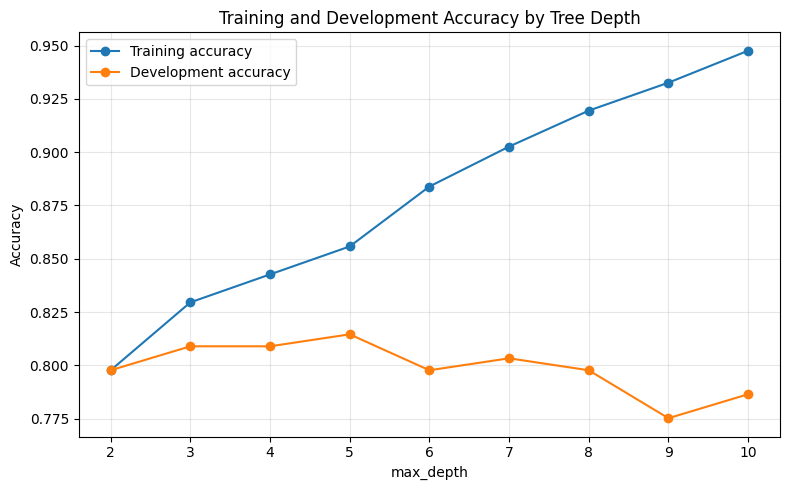

In [8]:
# Compare training and development accuracy across tree depths
plt.figure(figsize=(8, 5))
plt.plot(
    accuracy_results["max_depth"],
    accuracy_results["training_accuracy"],
    marker="o",
    label="Training accuracy",
)
plt.plot(
    accuracy_results["max_depth"],
    accuracy_results["development_accuracy"],
    marker="o",
    label="Development accuracy",
)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Training and Development Accuracy by Tree Depth")
plt.xticks(list(max_depth_values))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Accuracy analysis**

Training accuracy increases as `max_depth` grows, reaching 0.948 at depth 10. Development accuracy improves from depth 2 to depth 5, where it reaches 0.815, then declines as the tree becomes deeper. The widening gap between the two lines indicates overfitting: deeper trees learn increasingly specific patterns in the training data that do not generalise as well to unseen passengers. The optimal depth is therefore 5, where development performance is highest.

In [9]:
# Train the final model using the optimal max_depth and evaluate it on the test set
optimal_depth = int(
    accuracy_results.loc[
        accuracy_results["development_accuracy"].idxmax(), "max_depth"
    ]
)

final_tree = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
final_tree.fit(X_train, y_train)
final_test_accuracy = accuracy_score(y_test, final_tree.predict(X_test))

print(f"Selected optimal max_depth: {optimal_depth}")
print(f"Final model test accuracy: {final_test_accuracy:.3f}")

Selected optimal max_depth: 5
Final model test accuracy: 0.821


**Summary of findings**

The Titanic data was cleaned by removing identifier and text fields, filling missing `Age` values with the median and missing `Embarked` values with the mode, and one-hot encoding categorical variables with `drop_first=True` to avoid redundant dummy variables. The data was split into training, development, and test sets containing 60%, 20%, and 20% of the observations.

The unrestricted decision tree achieved a development accuracy of 0.753. Testing `max_depth` values from 2 to 10 showed that training accuracy increased as tree depth increased, while development accuracy peaked at `max_depth = 5` with an accuracy of 0.815 before declining. This gap indicates that deeper trees increasingly overfit the training data.

The final decision tree used `max_depth = 5` and achieved a test accuracy of 0.821. This model provides a useful prediction of passenger survival, while its performance also shows that survival depends on factors not fully captured by the selected variables.